# True DAG with networkx package

Draw the DAG based on the synthetic data generation. Use the networkx package to draw the DAG.

## Code setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import os

# Add modules to path:
import sys
sys.path.append('../')  # path to dir containing modules
from modules.create_data import create_stroke_data

## Create synthetic data

To make sure the names used here match the data.

In [2]:
df_synth = create_stroke_data(n=10, seed=42)
all_features = df_synth.columns

In [3]:
all_features

Index(['patient_id', 'year', 'age', 'ethnicity', 'male', 'afib', 'warfarin',
       'shoe_size', 'nihss', 'thrombolysis_time', 'thrombolysis',
       'mortality_prob_no_treatment', 'mortality_odds_no_treatment',
       'mortality_log_odds_no_treatment', 'mortality_prob_treated',
       'mortality_odds_treated', 'mortality_log_odds_treated',
       'odds_ratio_treated', 'log_odds_ratio_treated',
       'probability_difference', 'mortality_probability', 'died'],
      dtype='object')

Remove repeated columns in different units:

In [4]:
cols_to_drop = [
    'patient_id',
    # 'mortality_prob_no_treatment',
    'mortality_odds_no_treatment',
    'mortality_log_odds_no_treatment',
    'mortality_prob_treated',
    'mortality_odds_treated',
    'mortality_log_odds_treated',
    'odds_ratio_treated',
    'log_odds_ratio_treated',
    'probability_difference',
    # 'mortality_probability',
    'died'
]

In [5]:
all_features = [c for c in all_features if c not in cols_to_drop]

## Define linked factors

Set up a dataframe to store the effects between factors.

A value in the dataframe is 1 if the row factor affects the column factor, otherwise it is 0. Start with all values 0, i.e. no links, and manually set linked values:

In [6]:
# Start with all effects 0:
df_effects = (
    pd.DataFrame(columns=all_features, index=all_features, dtype=float)
        .fillna(0).astype(int)
)
df_effects.index.name = 'row_causes_column'

# Manually update links.
# Example: 'this' affects 'that': df_effects.loc['this', 'that'] = 1
df_effects.loc['age', 'afib'] = 1
df_effects.loc['afib', 'warfarin'] = 1
df_effects.loc['age', 'nihss'] = 1
df_effects.loc['age', 'mortality_prob_no_treatment'] = 1
df_effects.loc['afib', 'mortality_prob_no_treatment'] = 1
df_effects.loc['nihss', 'mortality_prob_no_treatment'] = 1
df_effects.loc['ethnicity', 'mortality_prob_no_treatment'] = 1
df_effects.loc['male', 'mortality_prob_no_treatment'] = 1
df_effects.loc['year', 'mortality_prob_no_treatment'] = 1
df_effects.loc['warfarin', 'thrombolysis'] = 1
df_effects.loc['nihss', 'thrombolysis'] = 1
df_effects.loc['thrombolysis', 'mortality_probability'] = 1
df_effects.loc['mortality_prob_no_treatment', 'mortality_probability'] = 1
df_effects.loc['ethnicity', 'mortality_probability'] = 1
df_effects.loc['thrombolysis_time', 'mortality_probability'] = 1

# Drop unused columns and rows.
# Drop parent nodes:
parent_nodes = df_effects.columns[df_effects.sum(axis='rows') == 0]
df_effects = df_effects.drop(parent_nodes, axis='columns')

In [7]:
df_effects

,afib,warfarin,nihss,thrombolysis,mortality_prob_no_treatment,mortality_probability
row_causes_column,,,,,,
year,0,0,0,0,1,0
age,1,0,1,0,1,0
ethnicity,0,0,0,0,1,1
male,0,0,0,0,1,0
afib,0,1,0,0,1,0
warfarin,0,0,0,1,0,0
shoe_size,0,0,0,0,0,0
nihss,0,0,0,1,1,0
thrombolysis_time,0,0,0,0,0,1


Save this:

In [8]:
df_effects.to_csv(os.path.join('data', 'synthetic_links.csv'))

## Set up adjacency matrix

Convert the above dataframe to an adjacency matrix.

Put the missing columns back in and make sure that they're in the same order as the index:

In [9]:
df_effects_full = df_effects.copy()
df_effects_full[parent_nodes] = 0
df_effects_full = df_effects_full[df_effects_full.index]

In [10]:
df_effects_full

,year,age,ethnicity,male,afib,warfarin,shoe_size,nihss,thrombolysis_time,thrombolysis,mortality_prob_no_treatment,mortality_probability
row_causes_column,,,,,,,,,,,,
year,0,0,0,0,0,0,0,0,0,0,1,0
age,0,0,0,0,1,0,0,1,0,0,1,0
ethnicity,0,0,0,0,0,0,0,0,0,0,1,1
male,0,0,0,0,0,0,0,0,0,0,1,0
afib,0,0,0,0,0,1,0,0,0,0,1,0
warfarin,0,0,0,0,0,0,0,0,0,1,0,0
shoe_size,0,0,0,0,0,0,0,0,0,0,0,0
nihss,0,0,0,0,0,0,0,0,0,1,1,0
thrombolysis_time,0,0,0,0,0,0,0,0,0,0,0,1


Convert to a networkx graph object:

In [11]:
G = nx.from_pandas_adjacency(df_effects_full, create_using=nx.DiGraph)

## Basic plot

Use mostly the default settings and manually position the nodes.

In [12]:
# Node positions:
pos = {
    'year': (4, 0),
    'age': (3, 0),
    'ethnicity': (6, 0),
    'male': (5, 0),
    'afib': (1, -1),
    'warfarin': (1, -2),
    'shoe_size': (7, 0),
    'nihss': (3, -1),
    'thrombolysis_time': (7, -3),
    'thrombolysis': (2, -3),
    'mortality_prob_no_treatment': (4, -2),
    'mortality_probability': (6, -4),
}

# Pick out coordinates of most extreme nodes:
node_x_min = min([p[0] for p in pos.values()])
node_x_max = max([p[0] for p in pos.values()])
node_y_min = min([p[1] for p in pos.values()])
node_y_max = max([p[1] for p in pos.values()])

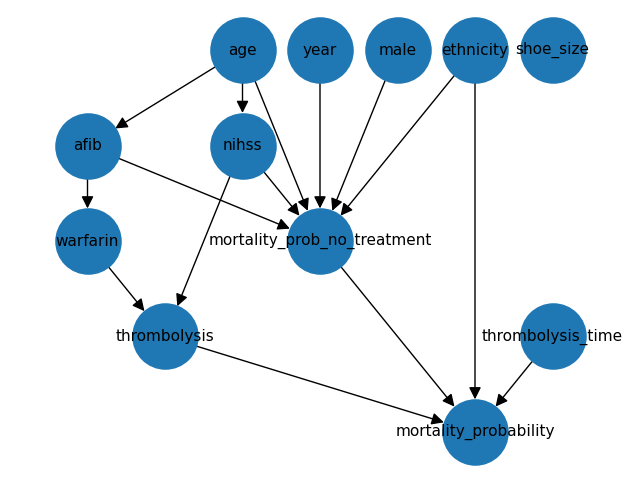

In [13]:
# Create graph:
fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx(
    G,
    pos,
    ax=ax,
    with_labels=True,
    arrows=True,
    node_size=2200,
    font_size=11,
    arrowsize=18,
)

# Modify axis limits for breathing room around labels:
ax.set_xlim(node_x_min-1, node_x_max+1)
# ax.set_ylim(node_y_min-1, node_y_max+1)

# Remove border around ax:
for s in ['top', 'bottom', 'left', 'right']:
    ax.spines[s].set_visible(False)

savename = os.path.join('images', 'true_dag_networkx.png')
plt.savefig(savename, bbox_inches='tight')
plt.show()

## Conclusion

We have used the networkx package to draw the "true" DAG based on our knowledge of the effects between factors.